# GoodDealDetector: Finding Houses with High Flipping Potential

## A tool to narrow searches for profitable real estate flips, simulate ROI from renovations, and help homeowners value their homes.

### Project Goal
This notebook goes beyond a standard price prediction. The project is split into two phases:
1.  **Regression:** We first build and tune a robust `XGBoost` model to accurately predict the "intrinsic value" of a house based on its features.
2.  **Classification:** We then use this regression model to engineer a new target variable: `Flipping_Potential`. We build a classifier to see if we can predict which properties are undervalued, have high renovation potential, and are in an area with high demand.

### Project Links
This notebook contains the full code. For a high-level overview of the business case and methodology, please see the links below.

* **Full Documentation:** [**README.md**](README.md)

## 1. Setup & Environment
We add the project root to the system path to enable imports from our custom `src` modules.

In [34]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Add project root to path to find 'src'
sys.path.append(os.path.abspath('..'))

# Import custom modular logic (using direct file imports)
from src.features.engineering import RANDOM_STATE
from src.models.train import (
    train_intrinsic_value_model, 
    train_flipping_potential_model,
    save_model
)
from src.models.helpers import calculate_flipping_potential

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 2. Data Loading & Initial Inspection

In [35]:
from pathlib import Path

# Define the project root relative to where the notebook is
# .resolve() gets the absolute path, .parent.parent moves up two levels
ROOT = Path.cwd() if Path("requirements.txt").exists() else Path.cwd().parent

DATA_PATH = ROOT / "GoodDealDetector" / "AmesHousing.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 2930 rows, 82 columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 3. Stage 1: Regression (Intrinsic Value Estimation)

Instead of manual preprocessing, we use our modular `train_intrinsic_value_model` function. This function automatically applies the full pipeline (feature engineering, imputation, encoding, and scaling) before fitting the XGBRegressor.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Define features and target (raw dollars)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# 2. Split data using our global RANDOM_STATE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# 3. Train the production-ready pipeline
# This handles feature engineering, imputation, and internal log-transform of target
reg_pipeline = train_intrinsic_value_model(X_train, y_train)

# 4. Evaluate the results
y_pred_dollar = reg_pipeline.predict(X_test)

rmse_dollar = np.sqrt(mean_squared_error(y_test, y_pred_dollar))
rmse_log = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(y_pred_dollar)))

print(f"Regression Model Dollar RMSE: ${rmse_dollar:,.2f}")
print(f"Regression Model Log-Scale RMSE: {rmse_log:.4f}")

Training Intrinsic Value Regressor...
Regression Model Dollar RMSE: $23,567.81
Regression Model Log-Scale RMSE: 0.1082


### 3.1 Conclusion & Business Value
We used the champion model to make final predictions and calculated its error in real-world terms (dollars).

* **Final Model RMSE (in Dollars):** `$23,567`
* **Final Model RMSE (log-scale):** `0.1082`



### **Takeaways:**

1. **For Sellers (Automated Price Setting)**
An agent can input a new client's home features into the pipeline and get an instant, unbiased "intrinsic value". This eliminates guesswork and provides a confident, data-backed starting point for a list price.

2. **For Buyers (Offer Validation)**
If the model predicts a value of $260,000 for a house listed at $300,000, the agent can advise their client that the house is overpriced and help them draft a data-supported lower offer.

3. **For Renovators (Basic ROI Simulation)**
An investor can take a house's data, manually change its features (e.g., KitchenQual from 'TA' to 'Ex'), and run both the "before" and "after" versions through the model to estimate the After Repair Value (ARV).

## 4. Stage 2: Classification (Identifying "Good Flips")

In this stage, we combine the **Regression** output with raw housing data to identify properties that are mathematically underpriced, have a solid structure, and high renovation potential.

In [37]:
# 1. Identify High-Demand Neighborhoods (Liquidity Condition)
# criteria: > 50 sales in the period
sale_by_neigh = df["Neighborhood"].value_counts()
high_demand_neighborhood_list = sale_by_neigh[sale_by_neigh > 50].index.tolist()

# 2. Get Intrinsic Value Predictions (Underpriced Condition)
# We use our reg_pipeline to predict on the entire dataset
X_all = df.drop("SalePrice", axis=1)
y_pred_intrinsic = reg_pipeline.predict(X_all)

# 3. Derive our Target using our modular helper
df["Flipping_Potential"] = calculate_flipping_potential(
    df, y_pred_intrinsic, high_demand_neighborhood_list
)

print(f"Houses flagged as 'Good Flips': {df['Flipping_Potential'].sum()}")
print(f"Percentage of market: {df['Flipping_Potential'].mean():.1%}")

Houses flagged as 'Good Flips': 835
Percentage of market: 28.5%


### 4.1 Training the Classifier

We use our modular `train_flipping_potential_model` which handles class imbalance automatically.

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

# Prepare features and target for classification
# We drop the synthetic target and the SalePrice
X_class = df.drop(["Flipping_Potential", "SalePrice"], axis=1)
y_class = df["Flipping_Potential"]

# Use same split for consistency
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=RANDOM_STATE
)

# Calculate ratio for imbalance handling
counts = y_train_c.value_counts()
ratio = counts.loc[0] / counts.loc[1]

# Train the Classifier Pipeline
clf_pipeline = train_flipping_potential_model(
    X_train_c, y_train_c, imbalanced_ratio=ratio
)

# Evaluate
y_pred_c = clf_pipeline.predict(X_test_c)
print("\nClassification Results:")
print(classification_report(y_test_c, y_pred_c))

Training Flipping Potential Classifier (Ratio: 2.55)...

Classification Results:
              precision    recall  f1-score   support

           0       0.97      0.66      0.78       412
           1       0.54      0.96      0.69       174

    accuracy                           0.75       586
   macro avg       0.76      0.81      0.74       586
weighted avg       0.85      0.75      0.76       586



## 4.2 Business Interpretation

The final **XGBClassifier** is tuned to prioritize opportunity capture, utilizing the class imbalance ratio (**2.55**) to bias the model toward identifying potential deals.

* **Recall = 96%** -> The model captures nearly all "Good Flip" opportunities. This minimizes the risk of **False Negatives**, which is critical because missing a high-alpha deal represents a total loss of projected profit.
* **Precision = 54%** -> When the model flags a property, there is a roughly 50/50 chance it is a true "Good Flip." While this creates "noise" in the form of **False Positives**, it still provides substantial leverage by filtering out the vast majority of non-viable listings.

**ROI Perspective**
This trade-off is optimal for a property investor. The cost of a False Positive is negligible (minimal time spent on manual vetting), whereas the cost of a False Negative is the entire opportunity cost of the deal. By maintaining high Recall at the expense of Precision, the model acts as an aggressive funnel that ensures no potential alpha is left on the table while drastically reducing the manual evaluation workload.

## 5. Visualizing the Model's Capability
We can visualize how well our model separates the "Good Flips" from the rest of the market.

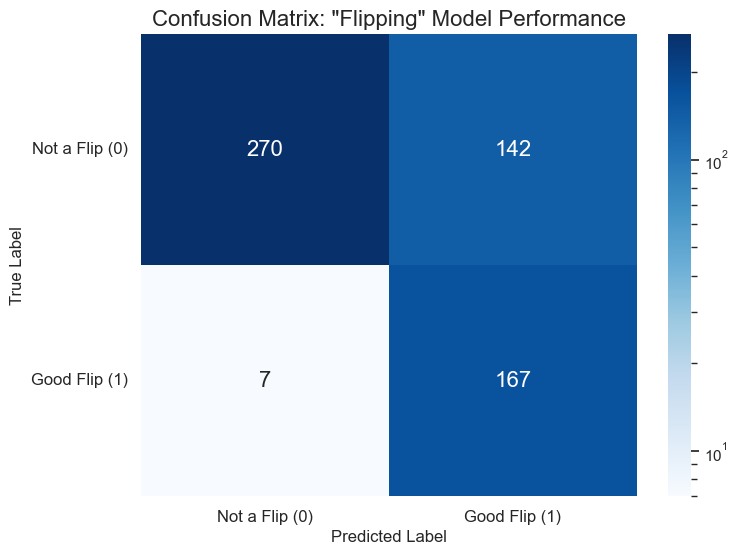

In [39]:
# Visualizing the confusion matrix
from matplotlib.colors import LogNorm 
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    cm, 
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws={"size": 16},
    norm=LogNorm()
)

ax.set_title('Confusion Matrix: "Flipping" Model Performance', fontsize=16)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.xaxis.set_ticklabels(['Not a Flip (0)', 'Good Flip (1)'], fontsize=12)
ax.yaxis.set_ticklabels(['Not a Flip (0)', 'Good Flip (1)'], fontsize=12, rotation=0)
plt.show()